In [1]:
%reset -f
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.data import Shapes_Dataset, TorusLieWrapper, AngleTorusWrapper, torus_embedding, PyGGraphWrapper
from torch_geometric.loader import DataLoader as PyGDataLoader
from matplotlib import patches
import src.plot as custom_plot
import src.diffusion as diffusion
import src.sde as sde
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties

/Users/jizho/project_codes/diffusion-playground/src/data.py:27: SyntaxWarning: invalid escape sequence '\i'
  """Map theta to x \in [a,b)"""
/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project_path = os.path.abspath('')
print(project_path)
print(torch.cuda.is_available())

/Users/jizho/project_codes/diffusion-playground
False



=== Variable num_points ===
  batch.x.shape:          torch.Size([235, 2])
  batch.pos.shape:        torch.Size([235, 2])
  batch.edge_index.shape: torch.Size([2, 6682])
  batch.edge_attr.shape:  torch.Size([6682, 2])
  batch.batch.shape:      torch.Size([235])
  sample 1's edge num:    torch.Size([930, 2])
  per-graph node counts:  [30, 31, 30, 27, 29, 28, 29, 31]

Done.


/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_13905/2949694544.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(xs[:,0], xs[:,1], c="steelblue", cmap="viridis")


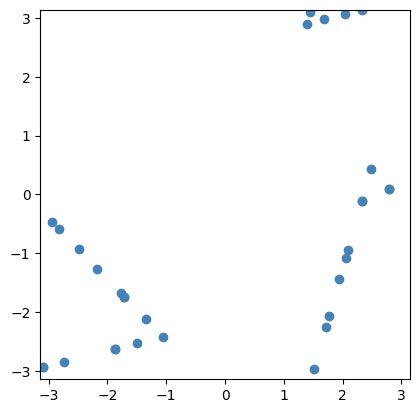

/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_13905/2949694544.py:48: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0, i].scatter(v_list[i][:,0], v_list[i][:,1], c="steelblue", cmap="viridis")
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_13905/2949694544.py:53: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1, i].scatter(pos_list[i][:,0], pos_list[i][:,1], c="steelblue", cmap="viridis")
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_13905/2949694544.py:69: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[2, i].scatter(xs[:,0], xs[:,1], c="red", cmap="viridis", alpha=0.5, label="start($t=0$)")
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_13905/2949694544.py:70: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[2, i].scatter(pos_list[i][:,0], pos_

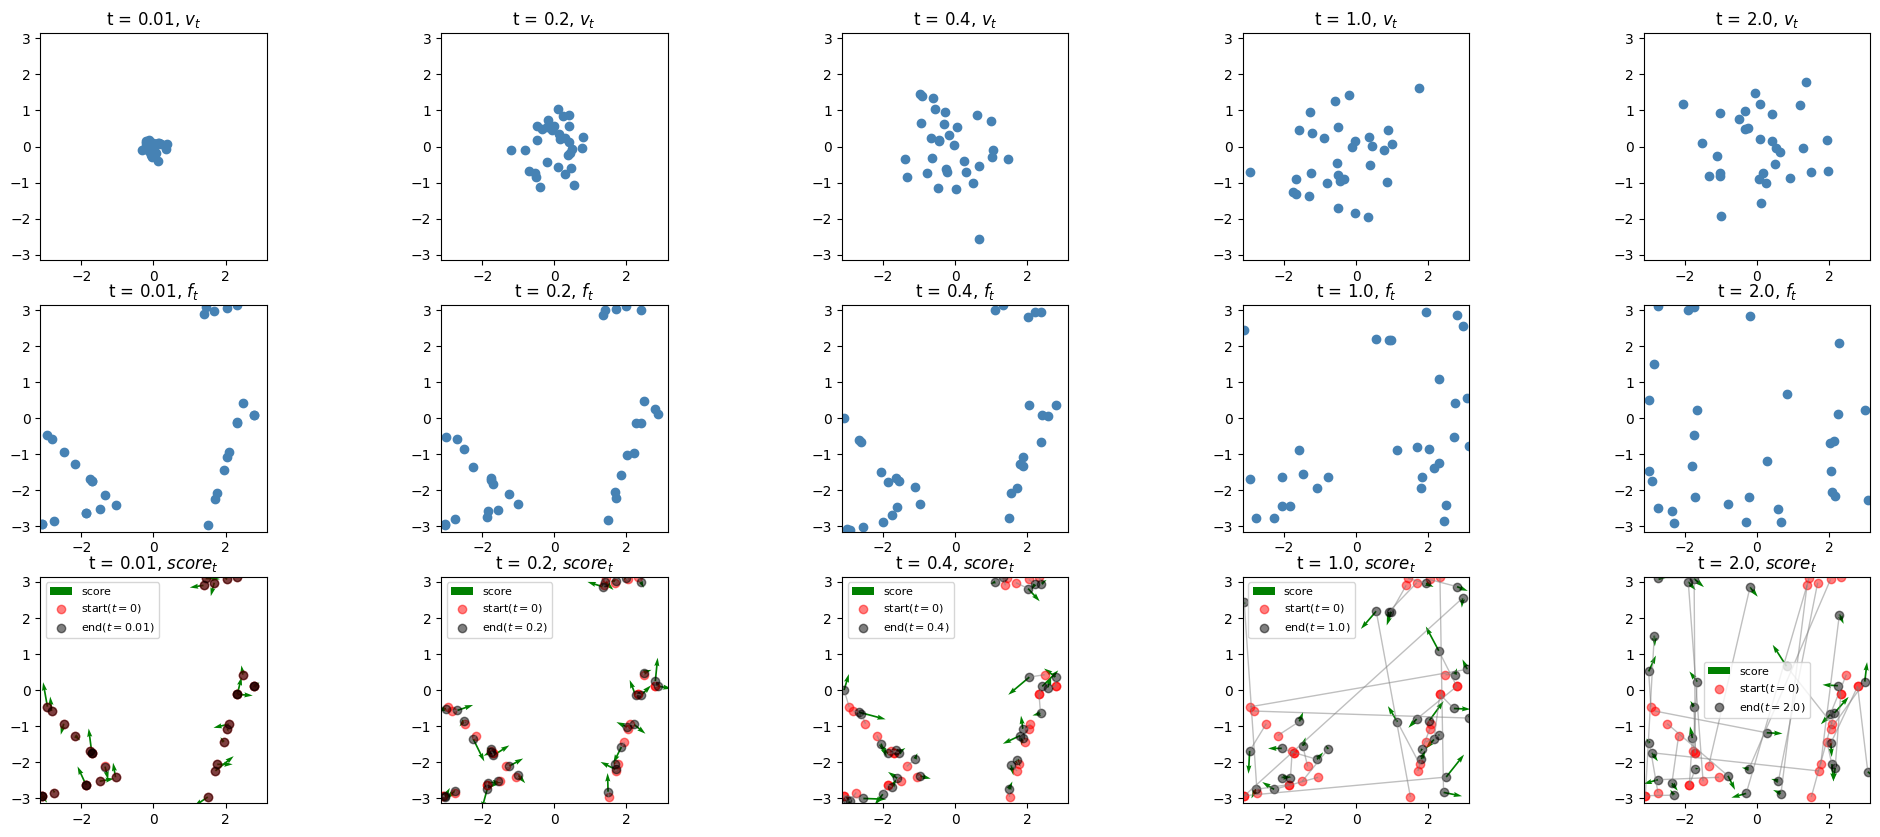

In [8]:
shape_dataset = Shapes_Dataset(num_points=32, dataset_size=10000, shape_types=["triangle"],scale_range=(0.2,0.8))
graph_dataset = PyGGraphWrapper(shape_dataset, num_points_range=(26,32))
graph_dataloader = PyGDataLoader(graph_dataset, batch_size=8, shuffle=True)
batch_1_graph = next(iter(graph_dataloader))
edge_graph = batch_1_graph.batch[batch_1_graph.edge_index[0]]
print("\n=== Variable num_points ===")
print(f"  batch.x.shape:          {batch_1_graph.x.shape}")
print(f"  batch.pos.shape:        {batch_1_graph.pos.shape}")
print(f"  batch.edge_index.shape: {batch_1_graph.edge_index.shape}")
print(f"  batch.edge_attr.shape:  {batch_1_graph.edge_attr.shape}")
print(f"  batch.batch.shape:      {batch_1_graph.batch.shape}")
print(f"  sample 1's edge num:    {batch_1_graph.edge_attr[edge_graph == 1].shape}")
# show per-graph node counts
counts = batch_1_graph.batch.bincount()
print(f"  per-graph node counts:  {counts.tolist()}")
print("\nDone.")

mask = batch_1_graph.batch == 1
xs = batch_1_graph.x[mask]
fig, ax = plt.subplots()
ax.scatter(xs[:,0], xs[:,1], c="steelblue", cmap="viridis")
ax.set_xlim(-torch.pi,torch.pi)
ax.set_ylim(-torch.pi,torch.pi)
ax.set_aspect("equal")
plt.show()



TDMmodel = diffusion.TDMDiffusion(dim=2, integrator_type="Euler", trunc_n=13, f_scale=2*torch.pi, total_time=2.0, simplified_param=True, n_sigma_rs=2000)

time_steps = [0.01,0.2,0.4,1.0,2.0]

v_list = []
pos_list = []
score_list = []
for t_step in time_steps:
    noised_sample_batch, score_batch, t_batch = TDMmodel.sample_forward_graph(batch_1_graph, 2.0, t_dist_kw="constant", v0_dist_kw="zero",constant_t = t_step, return_time=True)
    vt_batch, noised_graph_batch = noised_sample_batch
    mask = noised_graph_batch.batch == 1
    v_list.append(vt_batch[mask])
    pos_list.append(noised_graph_batch.pos[mask])
    score_list.append(score_batch[mask])


fig, axs = plt.subplots(3, 5, figsize=(25, 10))

for i, t_step in enumerate(time_steps):
    axs[0, i].scatter(v_list[i][:,0], v_list[i][:,1], c="steelblue", cmap="viridis")
    axs[0, i].set_title(f"t = {t_step}, $v_t$")
    axs[0, i].set_aspect("equal")
    axs[0, i].set_xlim(-torch.pi,torch.pi)
    axs[0, i].set_ylim(-torch.pi,torch.pi)
    axs[1, i].scatter(pos_list[i][:,0], pos_list[i][:,1], c="steelblue", cmap="viridis")
    axs[1, i].set_aspect("equal")
    axs[1, i].set_title(f"t = {t_step}, $f_t$")
    axs[1, i].set_xlim(-torch.pi,torch.pi)
    axs[1, i].set_ylim(-torch.pi,torch.pi)

    t = torch.tensor([t_step])
    prefactor = TDMmodel._get_prefector(t)
    sigma_norm_r_t = torch.sqrt(TDMmodel._sigma_norm_t(t))
    sigma_v = TDMmodel.sde.sigma_t(t)
    scorev_reverse = score_list[i] * prefactor * sigma_norm_r_t - v_list[i] / (sigma_v**2)
    segments = np.stack([pos_list[i], xs], axis=1)
    lc = LineCollection(segments, colors="gray", alpha=0.5,linewidths=1)
    axs[2, i].add_collection(lc)

    axs[2, i].quiver(pos_list[i][:,0], pos_list[i][:,1], score_list[i][:,0], score_list[i][:,1], color="green", cmap="viridis", label="score" )
    axs[2, i].scatter(xs[:,0], xs[:,1], c="red", cmap="viridis", alpha=0.5, label="start($t=0$)")
    axs[2, i].scatter(pos_list[i][:,0], pos_list[i][:,1], c="black", cmap="viridis", alpha=0.5, label=f"end($t={t_step}$)")
    axs[2, i].legend(prop=FontProperties(size=8))
    axs[2, i].set_aspect("equal")
    axs[2, i].set_title(f"t = {t_step}, $score_t$")
    axs[2, i].set_xlim(-torch.pi,torch.pi)
    axs[2, i].set_ylim(-torch.pi,torch.pi)

plt.show()


## Load the model and backward sampling

In [4]:
# -----------------------
# Config 
# -----------------------

from src.nn.vanillaGNN import TDM_VanillaGNN

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 32
n_epoch = 200
total_time = 2.0
num_mp_layers = 3
node_feat_dim = 2
edge_feat_dim = 2
v_dim = 2

# data shape: each sample -> (dim,)
dim = 2
# model
time_embedding_half_dim = 32  # must be even
time_embedding_scale = 1.0
position_fourier_bands = 8
with_sincos_position = True
only_sincos_position = True
t_dist_kw = "uniform"
hidden_dim = [512,512]
output_dim = dim

diffusion = diffusion.TDMDiffusion(dim=dim, integrator_type="Euler", simplified_param=True).to(device)
score_gnn = TDM_VanillaGNN(
    node_feat_dim=node_feat_dim,
    edge_feat_dim=edge_feat_dim,
    v_dim=v_dim,
    hidden_dim=hidden_dim,
    num_mp_layers=num_mp_layers,
    time_embedding_half_dim=time_embedding_half_dim,
    position_fourier_bands=position_fourier_bands,
    with_sincos_position=with_sincos_position,
    only_sincos_position=only_sincos_position,
    output_dim=output_dim,
    total_time=total_time,
    time_embedding_scale=time_embedding_scale,
).to(device)

state_dict = torch.load("vanilla_gnn_triangle_shapes.pt", map_location="cpu")

score_gnn.load_state_dict(state_dict)




<All keys matched successfully>

In [5]:
graph_nodes = [32,32,26,48,26,32]


ft_list, vt_list, t_list = diffusion.sample_backward_graph(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    graph_nodes = graph_nodes,
    data_dim = 2,
    total_time=2.0,
    tdm_score_fn=score_gnn.forward_from_data,
    sample_trajectory=True,
    n_steps = 20,
    exponential_integration=True,
    probability_flow=False,
    predictor_corrector=True,
    predictor_corrector_n_steps=20,
    only_correct_vt = True,
    tau = 1e-2
)


0
0 32
32
32 64
64
64 90
90
90 138
138
138 164
164
164 196


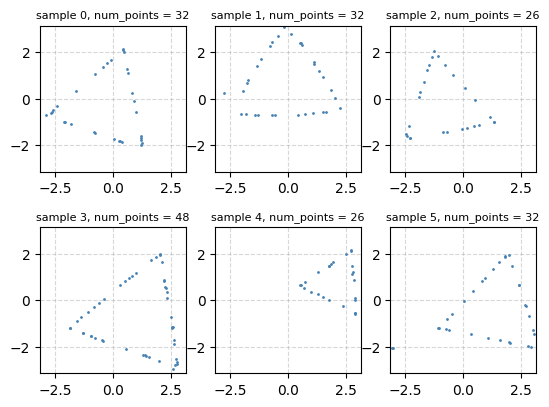

In [6]:
# extract the samples in a batch at time 0
f0_list = []
for i in range(len(graph_nodes)):
    accum = 0
    for j in range(i):
        accum += graph_nodes[j]
    print(accum)
    index_0 = accum
    index_1 = accum + graph_nodes[i]
    print(index_0, index_1)
    if i == len(graph_nodes) - 1:
        f0_list.append(ft_list[-1][index_0:])
    else:
        f0_list.append(ft_list[-1][index_0:index_1])

# print(f0_list[1][:,0].shape)
fig,axes = plt.subplots(2,3)
for i in range(2):
    for j in range(3):
        axes[i,j].scatter(f0_list[i*3+j][:,0], f0_list[i*3+j][:,1], c="steelblue", s = 1)
        axes[i,j].set_aspect("equal")
        axes[i,j].set_title(f"sample {i*3+j}, num_points = {graph_nodes[i*3+j]}", fontsize = 8)
        axes[i,j].set_xlim(-torch.pi,torch.pi)
        axes[i,j].set_ylim(-torch.pi,torch.pi)
        axes[i,j].grid(True, alpha = 0.5, linestyle = "--")
        axes[i,j].grid(True, which="both")
        axes[i,j].set_axisbelow(True)
plt.show()

## Illustrate the position trajectory of time-reversed process (single sample)

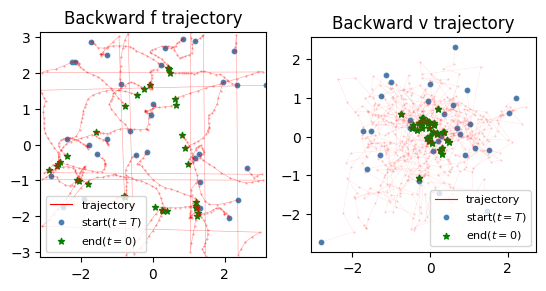

In [7]:


f_traj_x = [f[:graph_nodes[0],0].squeeze() for f in ft_list]
f_traj_y = [f[:graph_nodes[0],1].squeeze() for f in ft_list]

v_traj_x = [v[:graph_nodes[0],0].squeeze() for v in vt_list]
v_traj_y = [v[:graph_nodes[0],1].squeeze() for v in vt_list]
fig,axes = plt.subplots(1,2)
axes[0].plot(f_traj_x,f_traj_y, marker = "o", markersize = 0.5, linewidth = 0.4, alpha = 0.4, c = "red")
h_traj = Line2D([0],[0], color="red", linewidth=0.8, label="trajectory")
h_start = axes[0].scatter(f_traj_x[0],f_traj_y[0], marker = "o", s = 10, c = "steelblue", label = "start($t=T$)")
h_end = axes[0].scatter(f_traj_x[-1],f_traj_y[-1], marker = "*", s = 20, c = "green", label = "end($t=0$)")
axes[0].legend(handles=[h_traj, h_start, h_end], prop=FontProperties(size=8))
axes[0].set_xlim(-torch.pi,torch.pi)
axes[0].set_ylim(-torch.pi,torch.pi)
axes[0].set_aspect("equal")
axes[0].set_title("Backward f trajectory")

axes[1].plot(v_traj_x,v_traj_y, marker = "o", markersize = 0.5, linewidth = 0.2, alpha = 0.2, c = "red")
h_traj = Line2D([0],[0], color="red", linewidth=0.8, label="trajectory")
h_start = axes[1].scatter(v_traj_x[0],v_traj_y[0], marker = "o", s = 10, c = "steelblue", label = "start($t=T$)")
h_end = axes[1].scatter(v_traj_x[-1],v_traj_y[-1], marker = "*", s = 20, c = "green", label = "end($t=0$)")
axes[1].legend(handles=[h_traj, h_start, h_end], prop=FontProperties(size=8))
axes[1].scatter(v_traj_x[-1],v_traj_y[-1], marker = "*", s = 20, c = "green")
axes[1].set_aspect("equal")
axes[1].set_title("Backward v trajectory")

plt.show()

## Different sampling methods comparison

**Samplers**: 
- PC sampler with Exponential integrator
- P-only sampler with Exponential integrator
- Probability flow sampler with Exponential integrator


**Settings**:
- Simulated time steps: 20
- corrector steps: 20

In [8]:
graph_nodes = [32]
ft_list_pc, vt_list_pc, t_list_pc = diffusion.sample_backward_graph(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    graph_nodes = graph_nodes,
    data_dim = 2,
    total_time=2.0,
    tdm_score_fn=score_gnn.forward_from_data,
    sample_trajectory=True,
    n_steps = 20,
    exponential_integration=True,
    probability_flow=True,
    predictor_corrector=True,
    predictor_corrector_n_steps=20,
    only_correct_vt = True,
    tau = 1e-2,
    seed = 50
)

ft_list_ponly, vt_list_ponly, t_list_ponly = diffusion.sample_backward_graph(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    graph_nodes = graph_nodes,
    data_dim = 2,
    total_time=2.0,
    tdm_score_fn=score_gnn.forward_from_data,
    sample_trajectory=True,
    n_steps = 20,
    exponential_integration=True,
    probability_flow=False,
    predictor_corrector=False,
    predictor_corrector_n_steps=20,
    only_correct_vt = True,
    tau = 1e-2,
    seed = 50
)

ft_list_pf, vt_list_pf, t_list_pf = diffusion.sample_backward_graph(
    fT_prior_kw="uniform", 
    vT_prior_kw="stdGauss", 
    graph_nodes = graph_nodes,
    data_dim = 2,
    total_time=2.0,
    tdm_score_fn=score_gnn.forward_from_data,
    sample_trajectory=True,
    n_steps = 20,
    exponential_integration=True,
    probability_flow=True,
    predictor_corrector=False,
    predictor_corrector_n_steps=20,
    only_correct_vt = True,
    tau = 1e-2,
    seed = 50
)


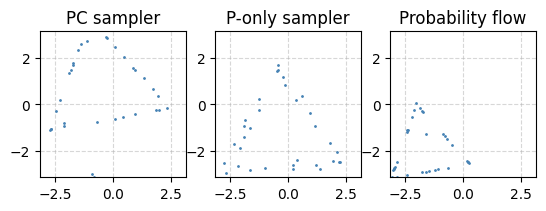

In [9]:
fig, axes = plt.subplots(1,3)
axes[0].scatter(ft_list_pc[-1][:,0], ft_list_pc[-1][:,1], c="steelblue", s = 1)
axes[0].set_aspect("equal")
axes[0].set_title("PC sampler")
axes[0].grid(True, alpha = 0.5, linestyle = "--")
axes[0].grid(True, which="both")
axes[0].set_axisbelow(True)
axes[0].set_xlim(-torch.pi,torch.pi)
axes[0].set_ylim(-torch.pi,torch.pi)
axes[1].scatter(ft_list_ponly[-1][:,0], ft_list_ponly[-1][:,1], c="steelblue", s = 1)
axes[1].set_aspect("equal")
axes[1].grid(True, alpha = 0.5, linestyle = "--")
axes[1].grid(True, which="both")
axes[1].set_axisbelow(True)
axes[1].set_xlim(-torch.pi,torch.pi)
axes[1].set_ylim(-torch.pi,torch.pi)
axes[1].set_title("P-only sampler")
axes[2].scatter(ft_list_pf[-1][:,0], ft_list_pf[-1][:,1], c="steelblue", s = 1)
axes[2].set_aspect("equal")
axes[2].grid(True, alpha = 0.5, linestyle = "--")
axes[2].grid(True, which="both")
axes[2].set_axisbelow(True)
axes[2].set_xlim(-torch.pi,torch.pi)
axes[2].set_ylim(-torch.pi,torch.pi)
axes[2].set_title("Probability flow")
plt.show()


